# 📈 Sales Prediction Using Python
**CodSoft Data Science Internship — Task 4**

---

Predicting product sales based on advertising spend across three channels —
TV, Radio, and Newspaper — using machine learning regression models.
The goal is to identify which advertising channel drives sales the most
and build a model that accurately forecasts sales from budget allocation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


## 1. Importing Libraries

Importing all necessary libraries for data handling, visualization,
preprocessing, and regression model training and evaluation.

In [2]:
df = pd.read_csv('./advertising.xls')
print(df)

        TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]


## 2. Loading the Dataset

Loading the advertising dataset into a Pandas DataFrame.
The dataset contains 200 records with 3 advertising budget features
(TV, Radio, Newspaper) and Sales as the target variable.

In [3]:
print(df.shape)
print('Info : ', df.info())
print('\nNull : ', df.isna().sum())
for col in df.columns:
    print(f'{col} -> {df[col].unique()}')

(200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
Info :  None

Null :  TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
TV -> [230.1  44.5  17.2 151.5 180.8   8.7  57.5 120.2   8.6 199.8  66.1 214.7
  23.8  97.5 204.1 195.4  67.8 281.4  69.2 147.3 218.4 237.4  13.2 228.3
  62.3 262.9 142.9 240.1 248.8  70.6 292.9 112.9  97.2 265.6  95.7 290.7
 266.9  74.7  43.1 228.  202.5 177.  293.6 206.9  25.1 175.1  89.7 239.9
 227.2  66.9 100.4 216.4 182.6 262.7 198.9   7.3 136.2 210.8 210.7  53.5
 261.3 239.3 102.7 131.1  69.   31.5 139.3 216.8 199.1 109.8  26.8 129.4
 213.4  16.9  27.5 120.5   5.4 116.   76.4 239.8  75.3  68.4 213.5 193.2
  76.3

## 3. Data Exploration

Examining the dataset's structure, data types, missing values,
and basic statistics before any processing.

The dataset contains 200 samples with no missing values — clean
and ready for analysis with no preprocessing required for nulls.

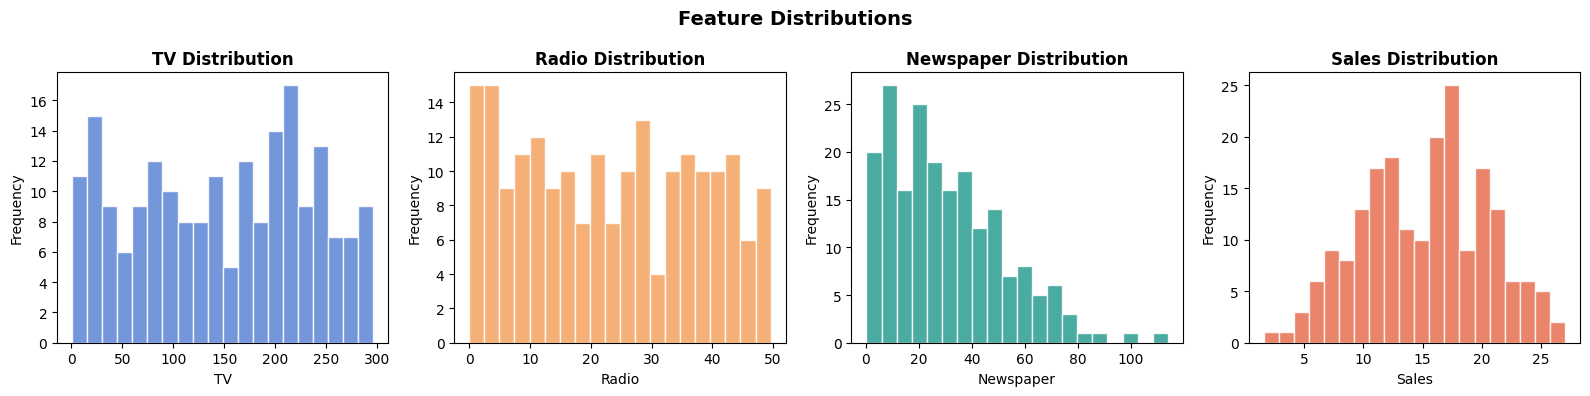

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['TV', 'Radio', 'Newspaper', 'Sales']
colors = ['#5C85D6', '#F4A261', '#2A9D8F', '#E76F51']

for ax, col, color in zip(axes, cols, colors):
    df[col].plot(kind='hist', bins=20, ax=ax, 
                 color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Distributions

Histograms showing the spread of each feature and the target variable.

**Key Observations:**
- **TV** — wide spread from near 0 to 300, fairly uniform distribution
- **Radio** — right skewed, most budgets are moderate (0–40 range)
- **Newspaper** — heavily right skewed, most spend is low with a few
  high outliers
- **Sales** — roughly bell shaped, centered around 12–16 units

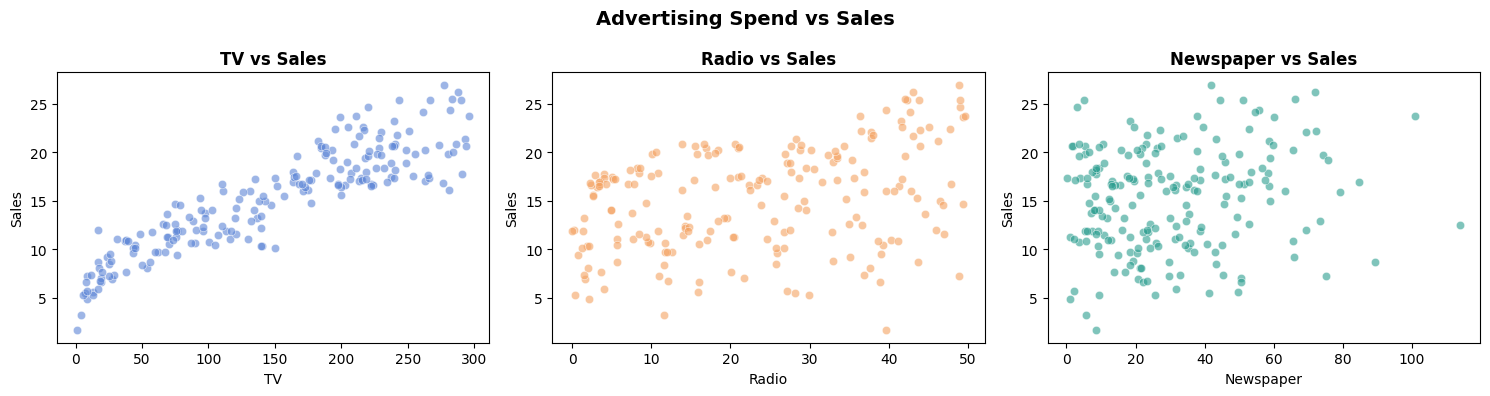

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['TV', 'Radio', 'Newspaper']
colors = ['#5C85D6', '#F4A261', '#2A9D8F']

for ax, feature, color in zip(axes, features, colors):
    ax.scatter(df[feature], df['Sales'], 
               color=color, alpha=0.6, edgecolors='white', linewidth=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel('Sales')
    ax.set_title(f'{feature} vs Sales', fontweight='bold')

plt.suptitle('Advertising Spend vs Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Advertising Spend vs Sales — Scatter Plots

Scatter plots reveal the relationship between each advertising channel
and sales figures.

**Key Observations:**
- **TV vs Sales** — strong positive linear relationship, as TV budget
  increases sales consistently rise — the clearest pattern of all three
- **Radio vs Sales** — moderate positive relationship, more scattered
  but still a visible upward trend
- **Newspaper vs Sales** — weakest relationship, points are widely
  scattered with no clear trend — suggests low predictive value

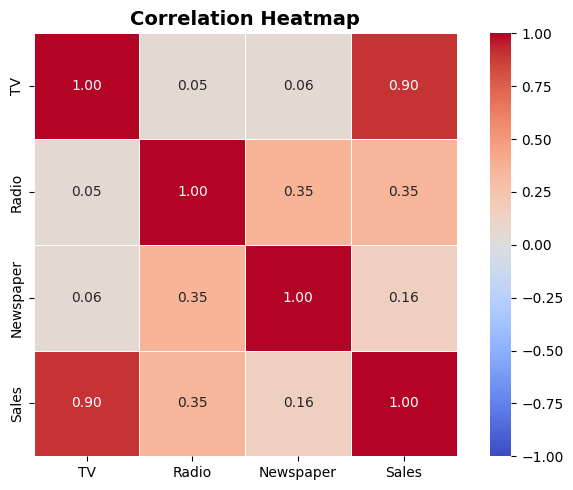

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

Pairwise correlations between all features and the target variable Sales.

**Key Observations:**
- **TV ↔ Sales** — strongest correlation, confirming TV is the dominant
  advertising channel for driving sales
- **Radio ↔ Sales** — moderate positive correlation, a secondary
  but meaningful contributor
- **Newspaper ↔ Sales** — weakest correlation, minimal relationship
  with sales outcomes
- **TV ↔ Newspaper** — slight positive correlation between channels,
  but not high enough to cause multicollinearity concerns

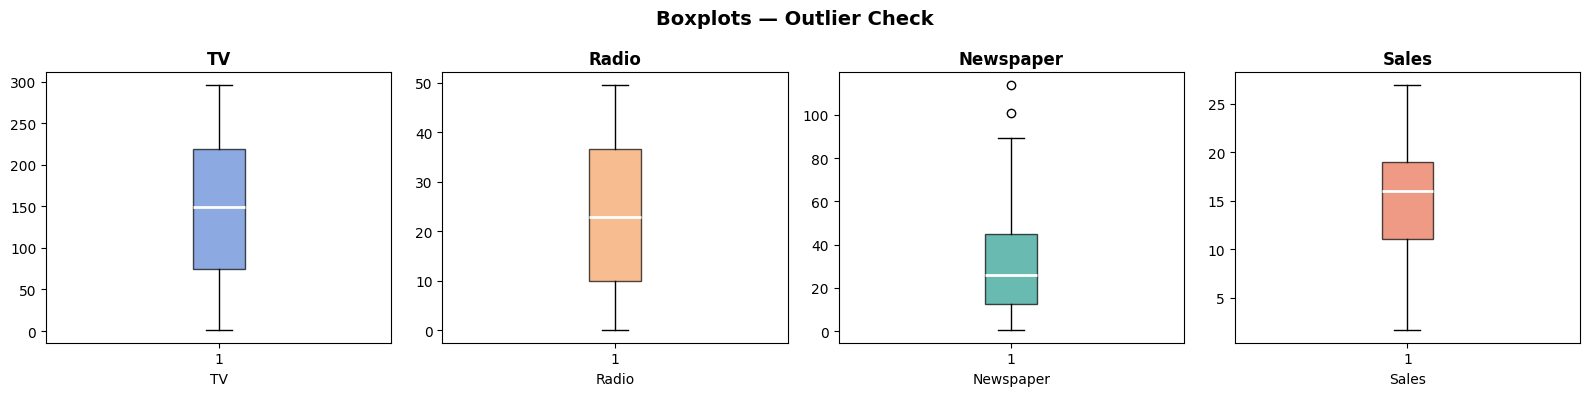

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['TV', 'Radio', 'Newspaper', 'Sales']
colors = ['#5C85D6', '#F4A261', '#2A9D8F', '#E76F51']

for ax, col, color in zip(axes, cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Boxplots — Outlier Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Boxplots — Outlier Check

Boxplots reveal the median, spread, and outliers in each column.

**Key Observations:**
- **TV** — fairly symmetric with a few low outliers, overall clean
- **Radio** — slightly right skewed, no extreme outliers
- **Newspaper** — notable high outliers, a few campaigns had
  unusually large newspaper budgets far above the typical range
- **Sales** — clean distribution, no extreme outliers in the target
  variable — good for model stability

In [8]:
features = ['TV', 'Radio', 'Newspaper']

X = df[features]
y = df['Sales']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample:\n", X.head())

Feature matrix shape: (200, 3)
Target shape: (200,)

Sample:
       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4


## 8. Defining Features and Target

We separate the dataset into:
- **X (feature matrix)** — 3 advertising spend columns: TV, Radio, Newspaper
- **y (target vector)** — Sales column the model predicts

This is a regression task — we predict a continuous numerical value
(sales units) rather than a category.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")

Train size : 160 samples
Test size  : 40 samples


## 9. Train-Test Split and Feature Scaling

- 80% training (160 samples) and 20% testing (40 samples)
- No stratify needed — this is regression, not classification
- **StandardScaler** applied to normalize features, fitted only on
  training data to prevent data leakage

In [10]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:<22} MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}")

Linear Regression      MAE: 1.27  RMSE: 1.71  R²: 0.9059
Ridge Regression       MAE: 1.27  RMSE: 1.71  R²: 0.9057
Lasso Regression       MAE: 1.27  RMSE: 1.71  R²: 0.9052
Random Forest          MAE: 0.92  RMSE: 1.20  R²: 0.9535


In [11]:
results_df = pd.DataFrame(results).T.round(4)
print("\nModel Comparison:\n")
print(results_df.sort_values('R2', ascending=False))


Model Comparison:

                      MAE    RMSE      R2
Random Forest      0.9171  1.1987  0.9535
Linear Regression  1.2748  1.7052  0.9059
Ridge Regression   1.2734  1.7074  0.9057
Lasso Regression   1.2701  1.7118  0.9052


## 10. Model Training and Comparison

We train 4 regression models and evaluate using three metrics:
- **MAE** — average prediction error in sales units
- **RMSE** — similar to MAE but penalises large errors more heavily
- **R²** — proportion of sales variance explained by the model (1.0 = perfect)

| Model | R² Score |
|---|---|
| Random Forest | 0.9535 ✅ |
| Linear Regression | 0.9059 |
| Ridge Regression | 0.9057 |
| Lasso Regression | 0.9052 |

**Random Forest clearly wins** — it captures non-linear relationships
between advertising spend and sales that linear models cannot.
All three linear models score nearly identically (~0.905), confirming
the data has non-linear patterns that regularization alone cannot fix.

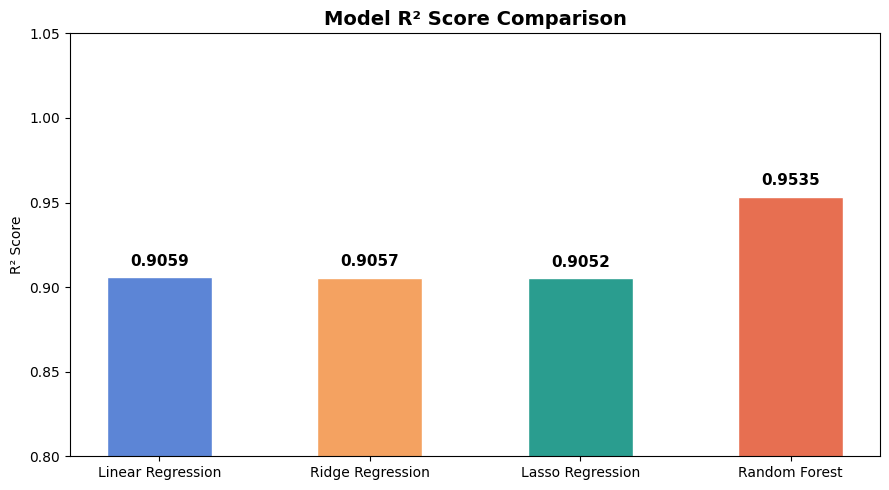

In [12]:
r2_scores = {name: v['R2'] for name, v in results.items()}

plt.figure(figsize=(9, 5))
bars = plt.bar(r2_scores.keys(),
               r2_scores.values(),
               color=['#5C85D6','#F4A261','#2A9D8F','#E76F51'],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, r2_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Model R² Score Comparison', fontsize=14, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0.8, 1.05)
plt.tight_layout()
plt.show()

## 11. Model R² Score Comparison — Bar Chart

Visual confirmation that Random Forest outperforms all linear models
by a meaningful margin (~4.5% R² gain). The y-axis starts at 0.80
to highlight the differences clearly.

In [13]:
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2   = r2_score(y_test, y_pred_best)

print("Best Model: Random Forest")
print("="*40)
print(f"  MAE  : {mae:.2f}  (avg prediction error in sales units)")
print(f"  RMSE : {rmse:.2f}  (penalises large errors more)")
print(f"  R²   : {r2:.4f} (model explains {r2*100:.2f}% of variance)")
print("="*40)

Best Model: Random Forest
  MAE  : 0.92  (avg prediction error in sales units)
  RMSE : 1.20  (penalises large errors more)
  R²   : 0.9535 (model explains 95.35% of variance)


## 12. Best Model Evaluation — Random Forest

| Metric | Value | Meaning |
|---|---|---|
| MAE | 0.92 | On average predictions are off by 0.92 sales units |
| RMSE | 1.20 | Larger errors are penalised — still very low |
| R² | 0.9535 | Model explains 95.35% of all sales variance |

These are strong results for a 3-feature dataset. The model generalises
well — an average error of under 1 sales unit on a scale of 5–25 is
excellent performance.

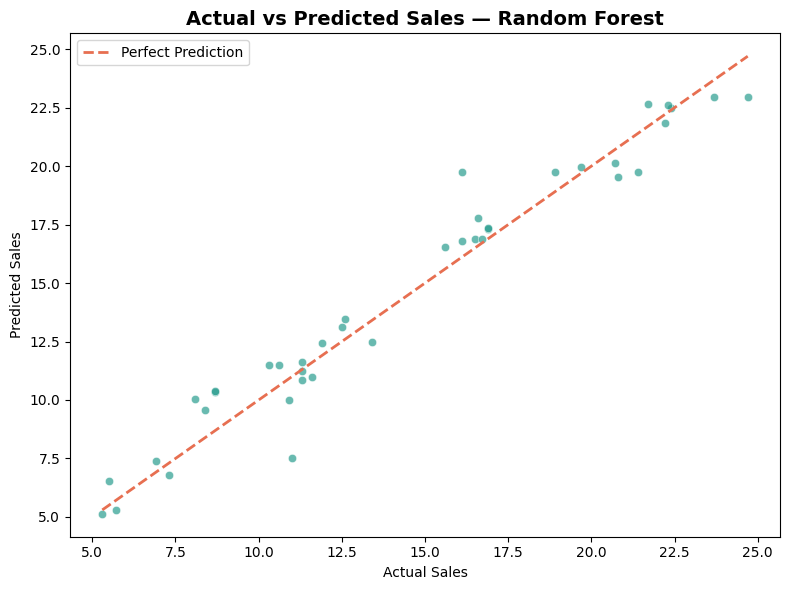

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, 
            color='#2A9D8F', alpha=0.7, 
            edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='#E76F51', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales — Random Forest', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Actual vs Predicted Sales

Points falling close to the red dashed line indicate accurate predictions.
The model tracks the diagonal very closely across the full sales range
(5–25 units), with only minor deviations at a few points.

The predictions are consistently accurate at both low and high sales
values — no systematic bias toward over or under-predicting.

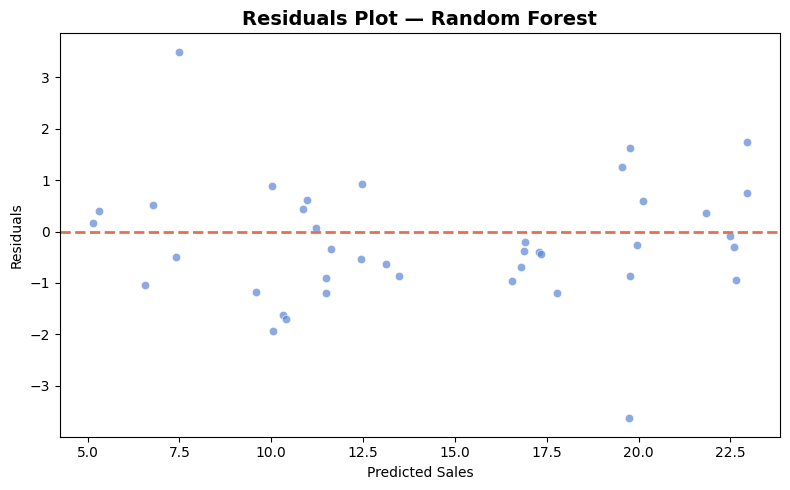

In [15]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals,
            color='#5C85D6', alpha=0.7,
            edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='#E76F51', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals Plot — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Residuals Plot

Residuals are the difference between actual and predicted sales.
A good model shows residuals scattered randomly around zero with
no clear pattern.

**Observations:**
- Most residuals fall between -2 and +2 — very small errors
- No systematic pattern visible — residuals are randomly distributed
- One slight outlier around predicted=7.5 (residual ~3.5) — a single
  unusual data point the model slightly underestimated
- Overall the random scatter confirms the model is not systematically
  biased in any direction

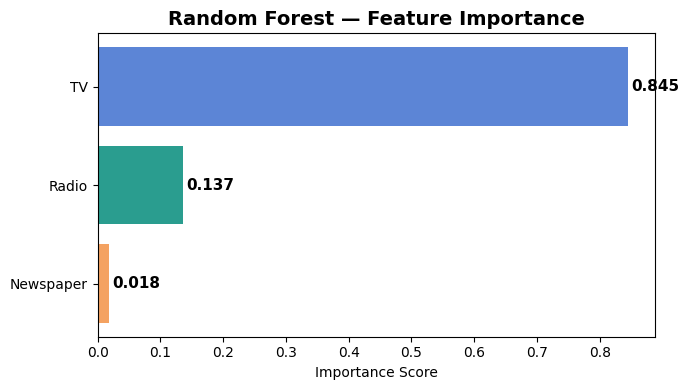

In [16]:
feat_imp = pd.Series(best_model.feature_importances_, 
                     index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
bars = plt.barh(feat_imp.index, feat_imp.values,
                color=['#F4A261', '#2A9D8F', '#5C85D6'])
plt.title('Random Forest — Feature Importance', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Feature Importance — Random Forest

| Feature | Importance |
|---|---|
| TV | 0.845 |
| Radio | 0.137 |
| Newspaper | 0.018 |

**TV advertising drives 84.5% of the model's decisions** — by far the
dominant channel. Radio contributes meaningfully at 13.7%. Newspaper
is almost irrelevant at just 1.8% — businesses could cut newspaper
spend with minimal impact on sales.

This is a powerful business insight: maximise TV budget first, use
Radio as a secondary channel, and reconsider Newspaper spend entirely.

In [17]:
sample = {
    'TV'        : 230.1,
    'Radio'     : 37.8,
    'Newspaper' : 69.2
}

sample_df     = pd.DataFrame([sample])
sample_scaled = scaler.transform(sample_df)
prediction    = best_model.predict(sample_scaled)[0]

print("="*45)
print(f"  TV Budget       : ${sample['TV']}k")
print(f"  Radio Budget    : ${sample['Radio']}k")
print(f"  Newspaper Budget: ${sample['Newspaper']}k")
print(f"  Predicted Sales : {prediction:.2f} units")
print("="*45)

  TV Budget       : $230.1k
  Radio Budget    : $37.8k
  Newspaper Budget: $69.2k
  Predicted Sales : 22.02 units


## 16. Live Prediction

Testing the model with a real advertising budget scenario:

| Channel | Budget |
|---|---|
| TV | $230.1k |
| Radio | $37.8k |
| Newspaper | $69.2k |

**Predicted Sales: 22.02 units**

Despite a high Newspaper budget ($69.2k), the prediction is driven
almost entirely by the strong TV spend ($230.1k) — consistent with
the feature importance findings. Try reducing TV spend to see how
dramatically the predicted sales drop.

In [18]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("💾 Saved model.pkl and scaler.pkl")

💾 Saved model.pkl and scaler.pkl
